In [1]:
# DAY 5 : Feature Engineering
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('../data/cleaned/student_lifestyle_cleaned.csv')

In [3]:
 print(df.shape)

(1000, 21)


In [4]:
#How many hours short of healthy sleep?
df['sleep_debt'] = 8 - df['sleep_hours']

print("sleep_debt created!")
print(f"Average sleep debt : {df['sleep_debt'].mean():.2f} hours")
print(f"Max sleep debt     : {df['sleep_debt'].max():.2f} hours")
print(f"Min sleep debt     : {df['sleep_debt'].min():.2f} hours")

sleep_debt created!
Average sleep debt : 1.69 hours
Max sleep debt     : 5.00 hours
Min sleep debt     : -2.00 hours


In [5]:
#Stress divided by sleep hours
df['stress_sleep_ratio'] = df['stress_level'] / df['sleep_hours']

print("stress_sleep_ratio created!")
print(f"Average ratio : {df['stress_sleep_ratio'].mean():.2f}")
print(f"Max ratio     : {df['stress_sleep_ratio'].max():.2f}")
print(f"Min ratio     : {df['stress_sleep_ratio'].min():.2f}")

stress_sleep_ratio created!
Average ratio : 0.97
Max ratio     : 3.03
Min ratio     : 0.11


In [6]:
 #Combined emotional state in one number
df['state_score'] = (
    df['stress_level'] +        # high is bad
    df['anxiety_score'] +       # high is bad
    (10 - df['mood_rating'])    # low mood is bad so we flip it
) / 3

print("state_score created!")
print(f"Average state score : {df['state_score'].mean():.2f}")
print(f"Max state score     : {df['state_score'].max():.2f}")
print(f"Min state score     : {df['state_score'].min():.2f}")

state_score created!
Average state score : 5.40
Max state score     : 9.67
Min state score     : 1.00


In [7]:
# Label students by screen time habit
def screen_category(hours):
    if hours <= 2:
        return 'Low'
    elif hours <= 5:
        return 'Moderate'
    else:
        return 'High'

df['screen_category'] = df['daily_screen_time_hrs'].apply(screen_category)

print("screen_category created!")
print(df['screen_category'].value_counts())

screen_category created!
screen_category
Moderate    710
High        195
Low          95
Name: count, dtype: int64


In [8]:
#Flag students who are at academic risk
df['at_risk'] = (
    (df['stress_level'] >= 7) &
    (df['sleep_hours'] <= 5) &
    (df['GPA'] <= 2.5)
).astype(int)

print("at_risk flag created!")
print(f"At risk students  : {df['at_risk'].sum()}")
print(f"Safe students     : {(df['at_risk'] == 0).sum()}")

at_risk flag created!
At risk students  : 68
Safe students     : 932


In [9]:
df.to_csv('../data/cleaned/student_lifestyle_engineered.csv', index=False)

print("Engineered dataset saved!")
print(f"Total columns now : {df.shape[1]}")
print(f"\nNew columns added:")
new_cols = ['sleep_debt', 'stress_sleep_ratio', 
            'state_score', 'screen_category', 'at_risk']
for col in new_cols:
    print(f"   → {col}")

Engineered dataset saved!
Total columns now : 26

New columns added:
   → sleep_debt
   → stress_sleep_ratio
   → state_score
   → screen_category
   → at_risk


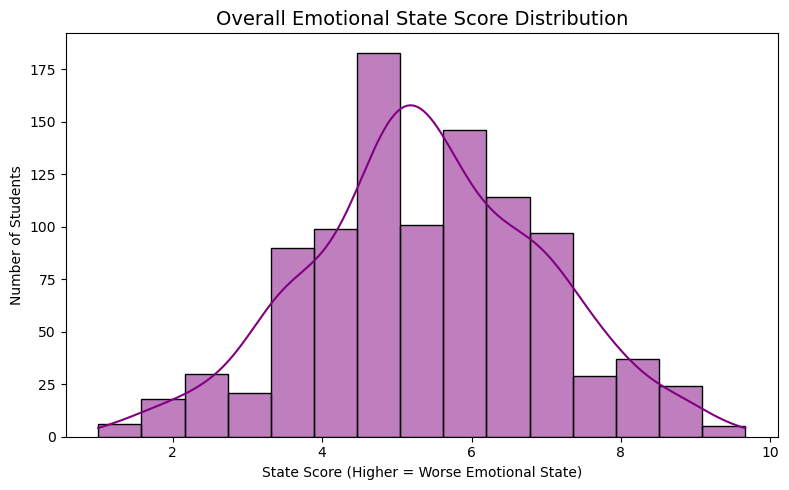

Chart saved!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['state_score'], bins=15, kde=True, color='purple')
plt.title('Overall Emotional State Score Distribution', fontsize=14)
plt.xlabel('State Score (Higher = Worse Emotional State)')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.savefig('../reports/figures/07_state_score_distribution.png')
plt.show()
print("Chart saved!")